In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [4]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelenght')

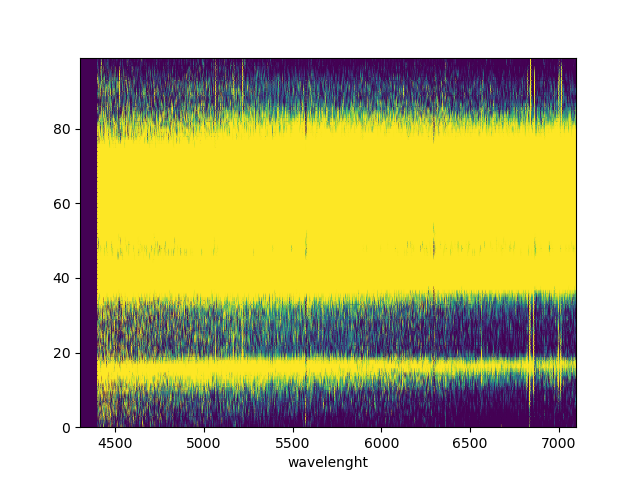

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.04263
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

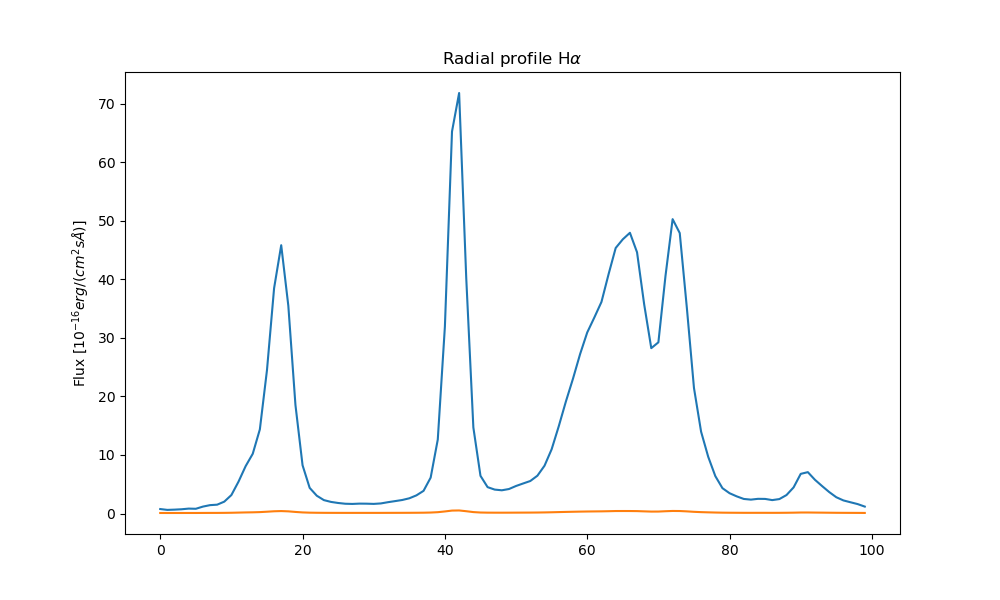

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

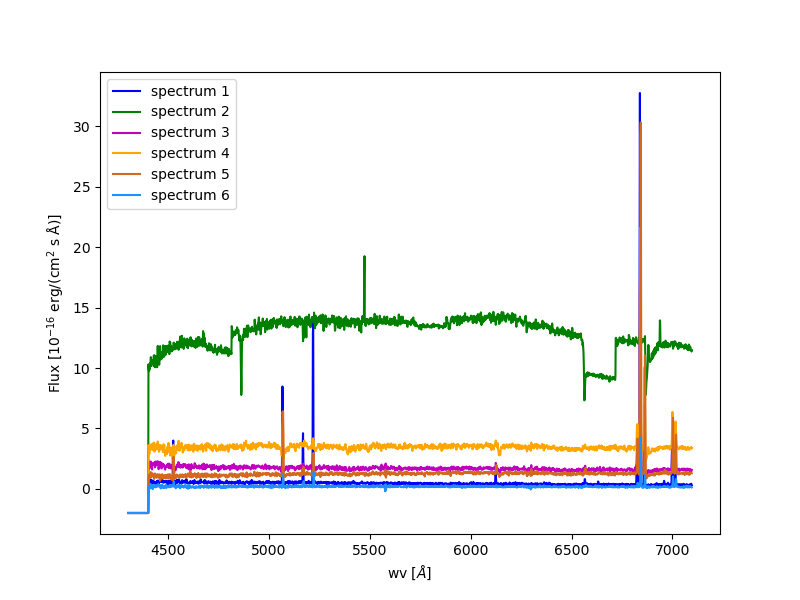

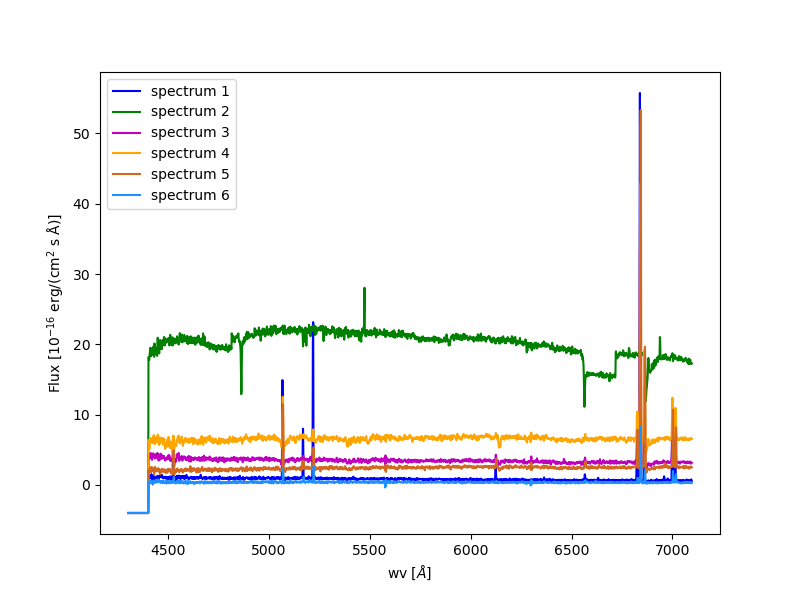

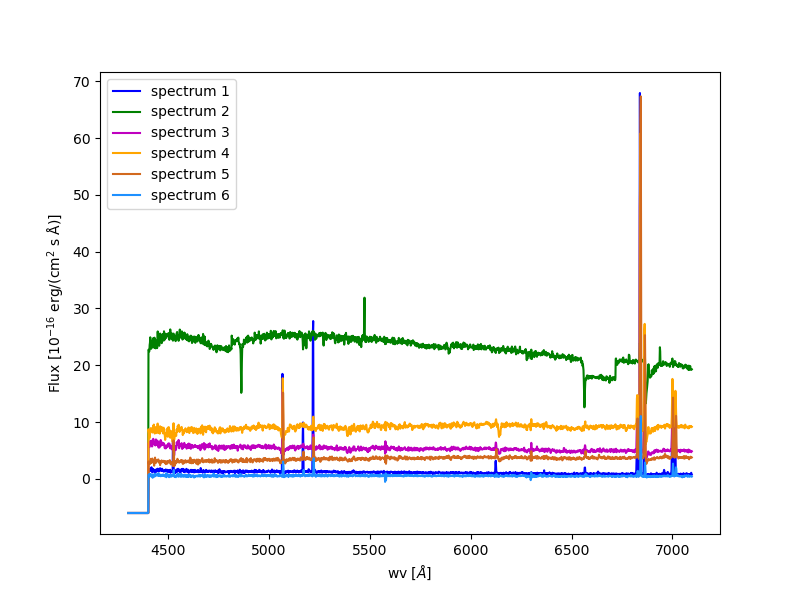

In [8]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/Halpha_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigma = seeing[-1] / 2.35
peaks = fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green','m', 'orange', 'chocolate', 'dodgerblue']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('1Sigma', f'Spectrum_1s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('2Sigma', f'Spectrum_2s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)
    
plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('3Sigma', f'Spectrum_3s_{i+1}.txt') 
    np.savetxt(filename, spectrum_table)

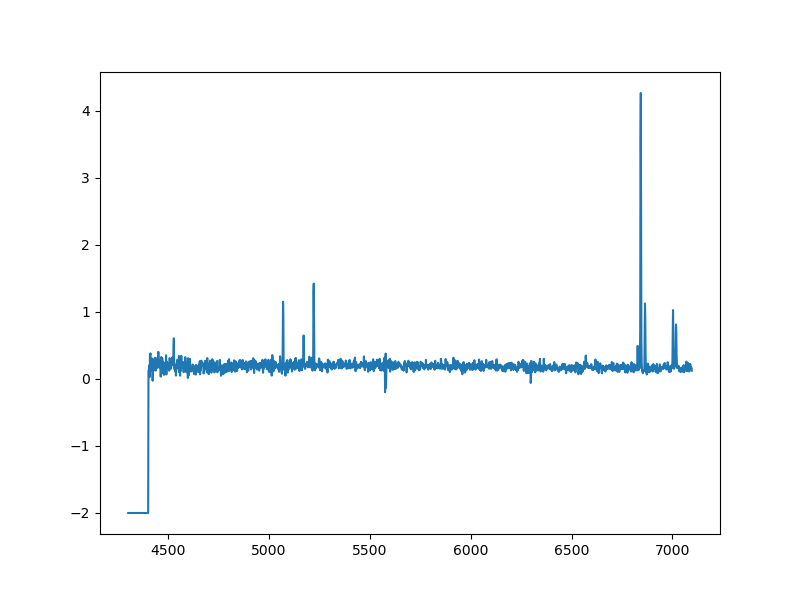

In [9]:
plt.figure(figsize=(8,6))
plt.plot(wv, spectra_1[5])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [10]:
import pandas as pd

mask_continuum_1 = (wv > 4600)*(wv < 4900)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6400)*(wv < 6700)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_1[i, mask_continuum_1])
    noise_1 = np.std(spectra_1[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_1[i, mask_continuum_2])
    noise_2 = np.std(spectra_1[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_1[i, mask_continuum_3])
    noise_3 = np.std(spectra_1[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df_path_signal = os.path.join('1Sigma', 'Signal_1s_continuum.csv')
df_path_noise = os.path.join('1Sigma', 'Noise_1s_continuum.csv')
df_path_combined = os.path.join('1Sigma', 'Combined_1s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('1Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    7.414846   15.987000   15.369851   20.786055   11.202812   
Continuum_2    8.270646   31.490396   17.078322   21.255989   14.406893   
Continuum_3    5.722171    6.222149   17.179569   28.856763   15.203446   

             Spectrum_6  
Continuum_1    3.294595  
Continuum_2    3.828626  
Continuum_3    4.205426  

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    0.528062   12.002714    1.801321    3.442057    1.117096   
Continuum_2    0.459840   13.815510    1.694405    3.458686    1.253052   
Continuum_3    0.366467   11.170140    1.572731    3.345607    1.258346   

             Spectrum_6  
Continuum_1    0.178234  
Continuum_2    0.198615  
Continuum_3    0.172497  

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    0.071217    0.750780    0.117198    0.165595    

In [11]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_2[i, mask_continuum_1])
    noise_1 = np.std(spectra_2[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_2[i, mask_continuum_2])
    noise_2 = np.std(spectra_2[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_2[i, mask_continuum_3])
    noise_3 = np.std(spectra_2[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df_path_signal = os.path.join('2Sigma', 'Signal_2s_continuum.csv')
df_path_noise = os.path.join('2Sigma', 'Noise_2s_continuum.csv')
df_path_combined = os.path.join('2Sigma', 'Combined_2s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('2Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    9.198189   19.633452   20.156019   23.977888   13.382003   
Continuum_2    9.311030   35.196742   20.310902   22.298936   17.088270   
Continuum_3    6.177136    9.215794   20.264238   33.585272   17.351327   

             Spectrum_6  
Continuum_1    4.379769  
Continuum_2    4.480217  
Continuum_3    4.847732  

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    0.967974   20.096302    3.663552    6.373031    2.153838   
Continuum_2    0.844255   21.469154    3.456883    6.574015    2.430688   
Continuum_3    0.670989   17.418006    3.199199    6.459063    2.455476   

             Spectrum_6  
Continuum_1    0.356137  
Continuum_2    0.387021  
Continuum_3    0.337848  

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    0.105235    1.023575    0.181760    0.265788    

In [12]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_3[i, mask_continuum_1])
    noise_1 = np.std(spectra_3[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_3[i, mask_continuum_2])
    noise_2 = np.std(spectra_3[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_3[i, mask_continuum_3])
    noise_3 = np.std(spectra_3[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df_path_signal = os.path.join('3Sigma', 'Signal_3s_continuum.csv')
df_path_noise = os.path.join('3Sigma', 'Noise_3s_continuum.csv')
df_path_combined = os.path.join('3Sigma', 'Combined_3s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('3Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    9.577237   19.330030   22.488808   26.016809   16.017182   
Continuum_2    9.822072   33.068211   21.860161   22.439062   18.402971   
Continuum_3    6.477074   10.198103   24.297250   36.105721   18.867309   

             Spectrum_6  
Continuum_1    5.057226  
Continuum_2    4.994738  
Continuum_3    5.852907  

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    1.316904   23.700646    5.636444    8.695687    3.147322   
Continuum_2    1.154326   24.365528    5.328236    9.143146    3.589555   
Continuum_3    0.911192   19.588337    4.935268    9.057551    3.669118   

             Spectrum_6  
Continuum_1    0.529183  
Continuum_2    0.568067  
Continuum_3    0.495160  

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    0.137504    1.226105    0.250633    0.334233    

## Redshift

In [13]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Numero di righe trovate (regione centrale, wv > 4451 Å): 26
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 4524.219999999934   emission                64
 5065.899999999774   emission               430
 5168.019999999744   emission               499
 5218.339999999729   emission               533
 6124.099999999462   emission              1145
 6824.139999999255   emission              1618
 6838.939999999251   emission              1628
 6859.659999999245   emission              1642
 6998.779999999204   emission              1736
   7013.5799999992   emission              1746
 6793.059999999265 absorption              1597
 6852.259999999247 absorption              1637
 6868.539999999242 absorption              1648
 6892.219999999235 absorption              1664
 6907.019999999231 absorption              1674
 6912.939999999229 absorption              1678
 6920.339999999227 absorptio


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Numero di righe trovate (regione centrale, wv > 4451 Å): 25
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 5472.899999999654   emission               705
 6112.259999999465   emission              1137
 6153.699999999453   emission              1165
 6161.099999999451   emission              1170
6183.2999999994445   emission              1185
 6205.499999999438   emission              1200
 6211.419999999436   emission              1204
 6220.299999999434   emission              1210
 6243.979999999427   emission              1226
 6272.099999999418   emission              1245
 6838.939999999251   emission              1628
 6938.099999999222   emission              1695
  4775.81999999986 absorption               234
4783.2199999998575 absorption               239
 4790.619999999855 absorption               244
 4793.579999999854 absorption               246
 4798.019999999853 absorptio

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12836\779506826.py:54: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f3, ax3 = plt.subplots(figsize=(10,8))


Numero di righe trovate (regione centrale, wv > 4451 Å): 12
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
4527.179999999933   emission                66
5068.859999999773   emission               432
5170.979999999743   emission               501
5221.299999999728   emission               535
6827.099999999255   emission              1620
 6843.37999999925   emission              1631
6864.099999999244   emission              1645
7003.219999999203   emission              1739
7018.019999999198   emission              1749
5579.459999999623 absorption               777
6297.259999999411 absorption              1262
6872.979999999241 absorption              1651


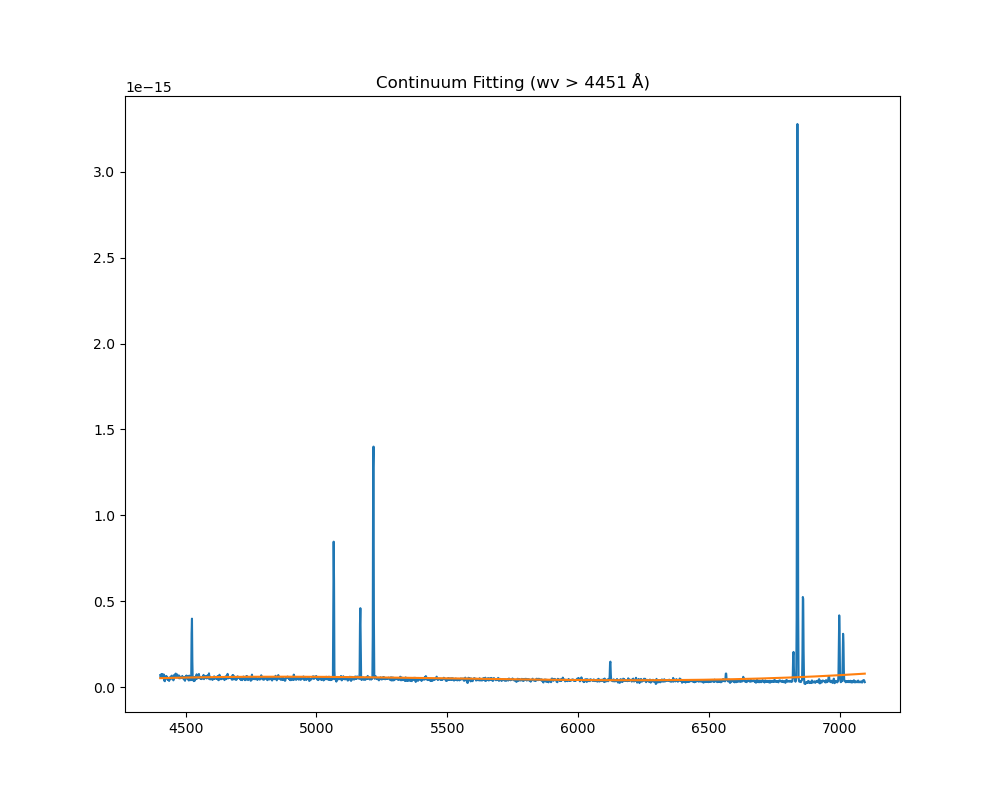

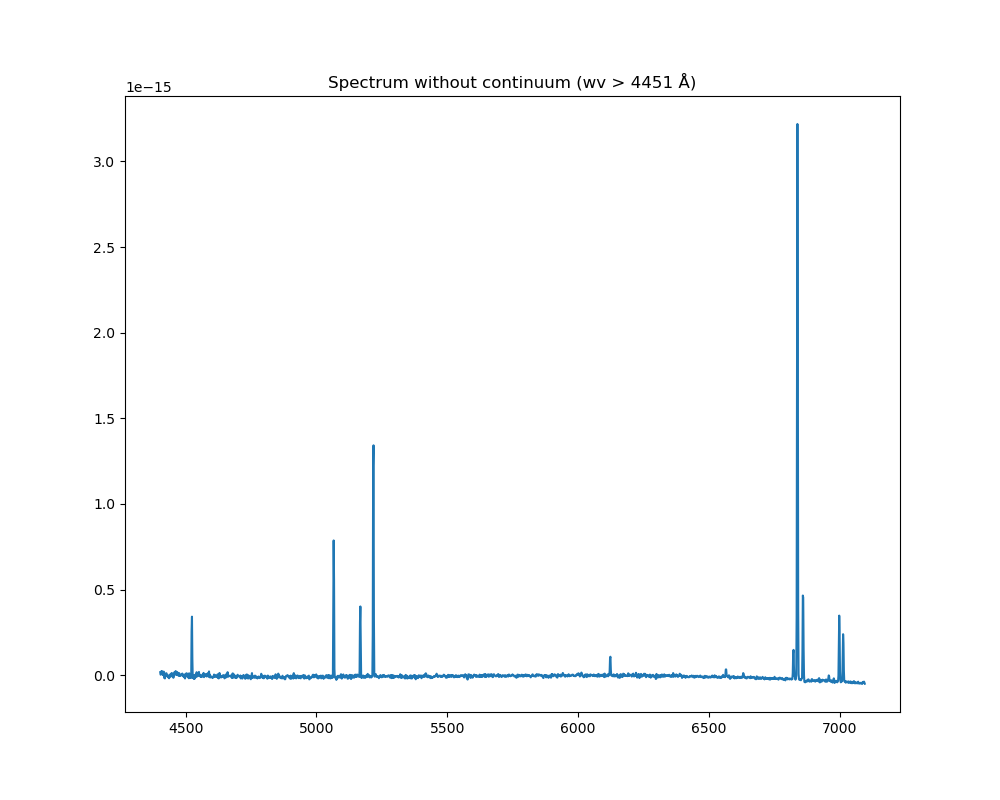

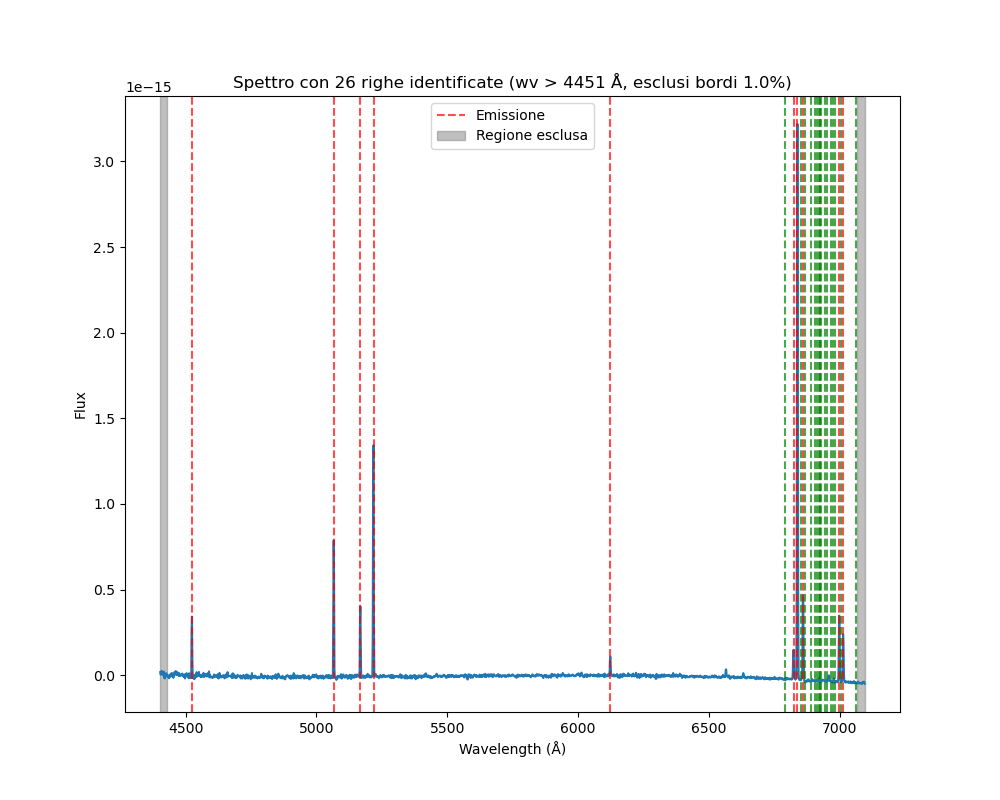

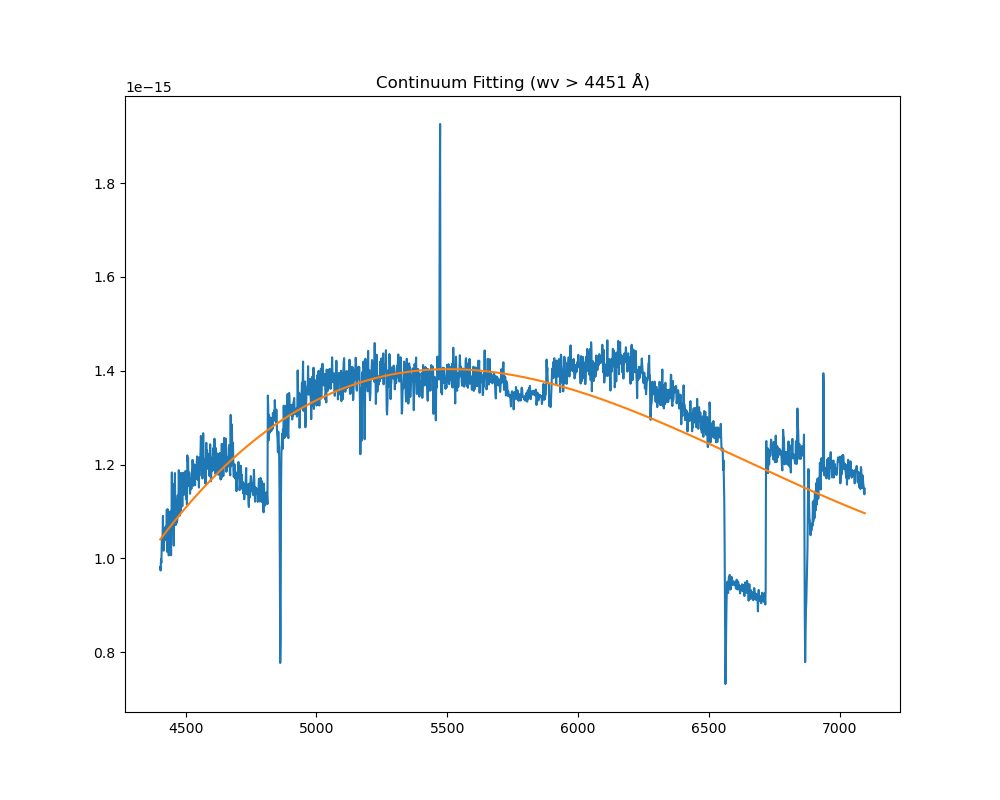

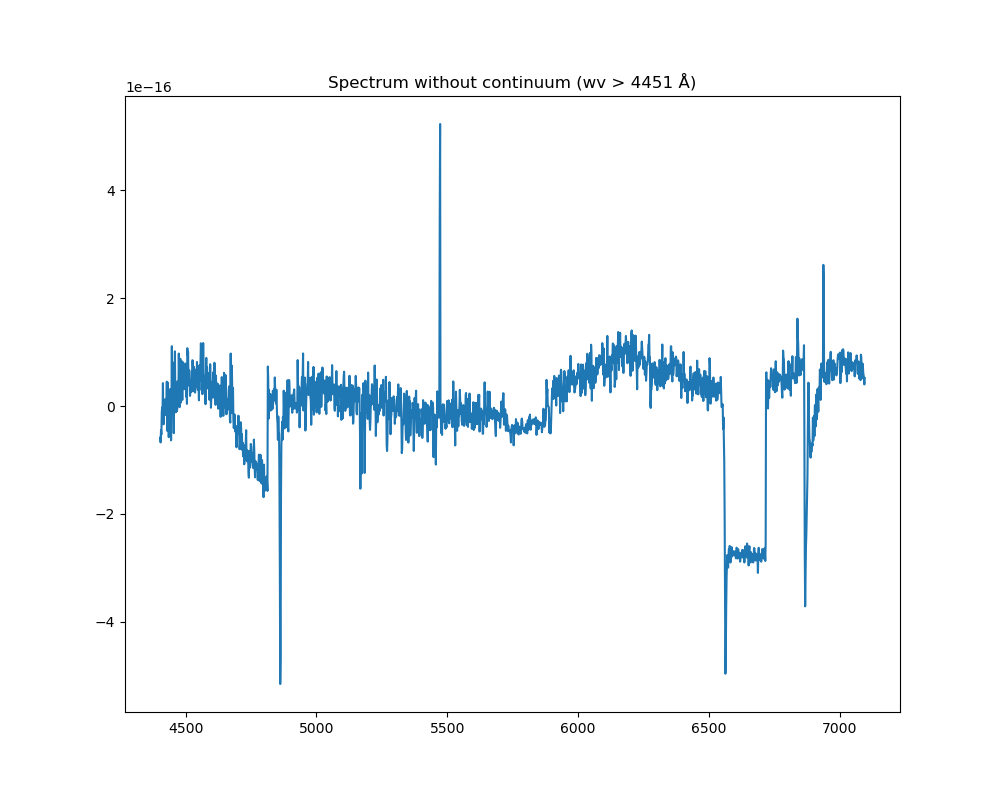

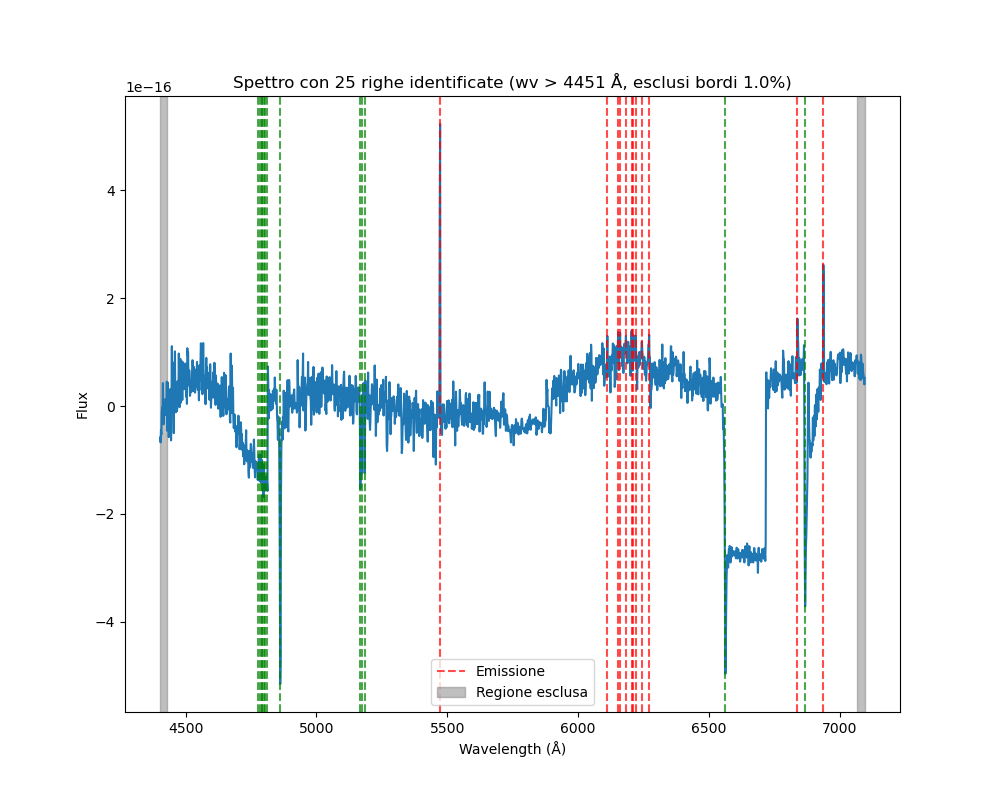

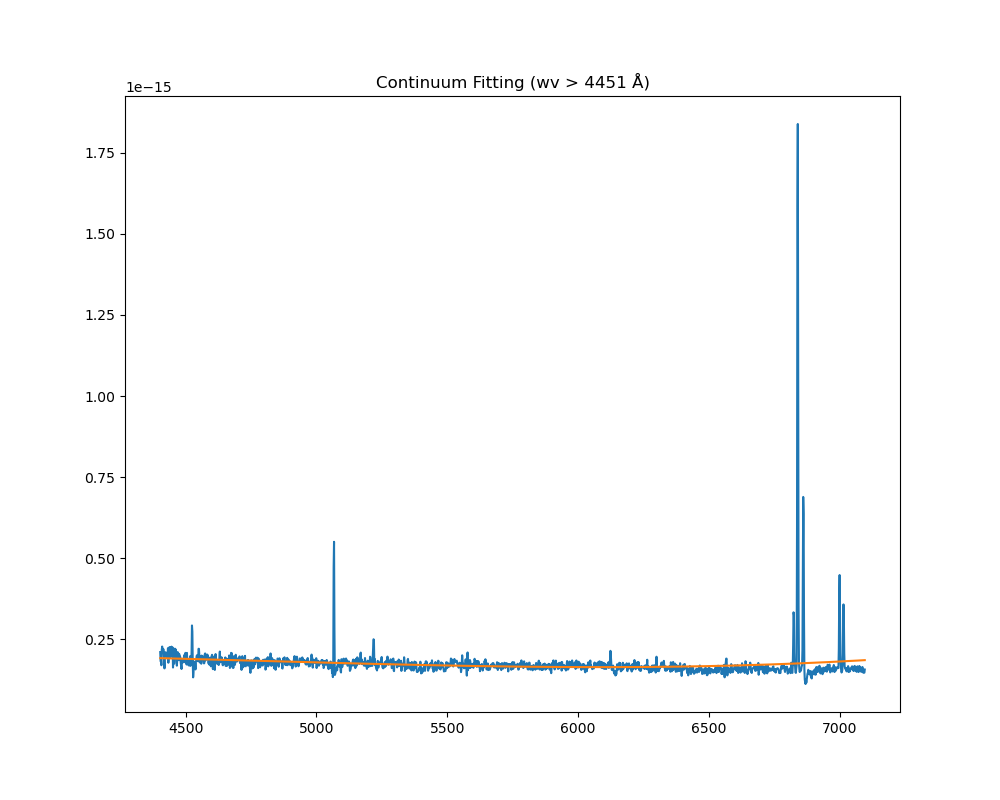

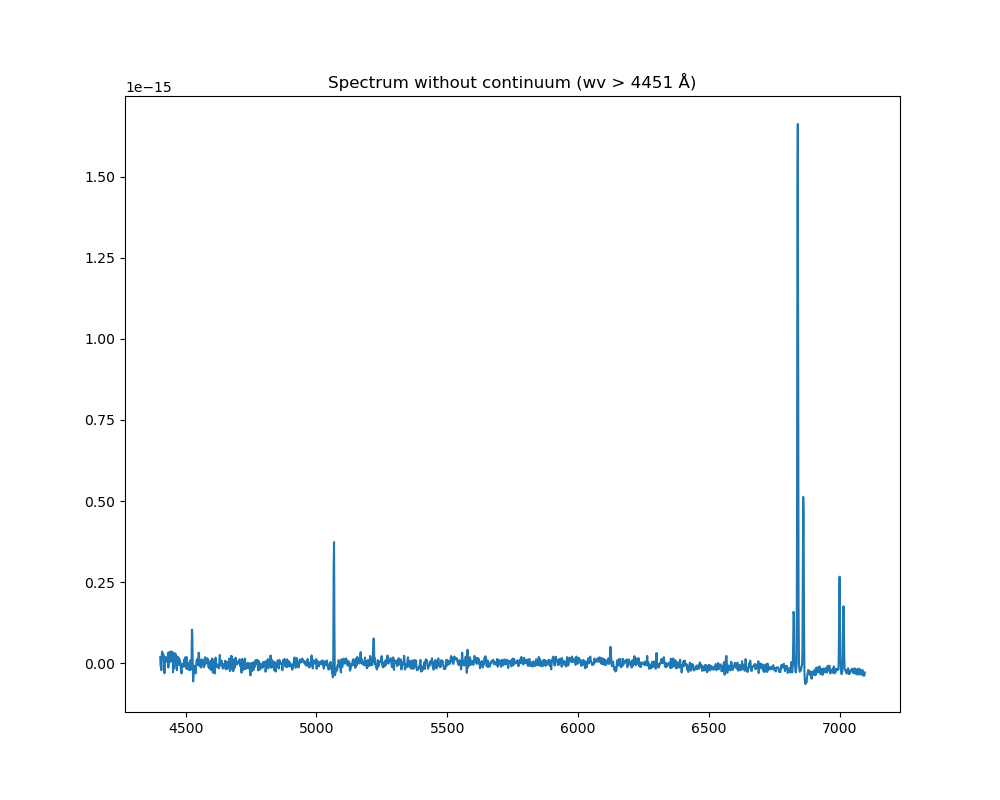

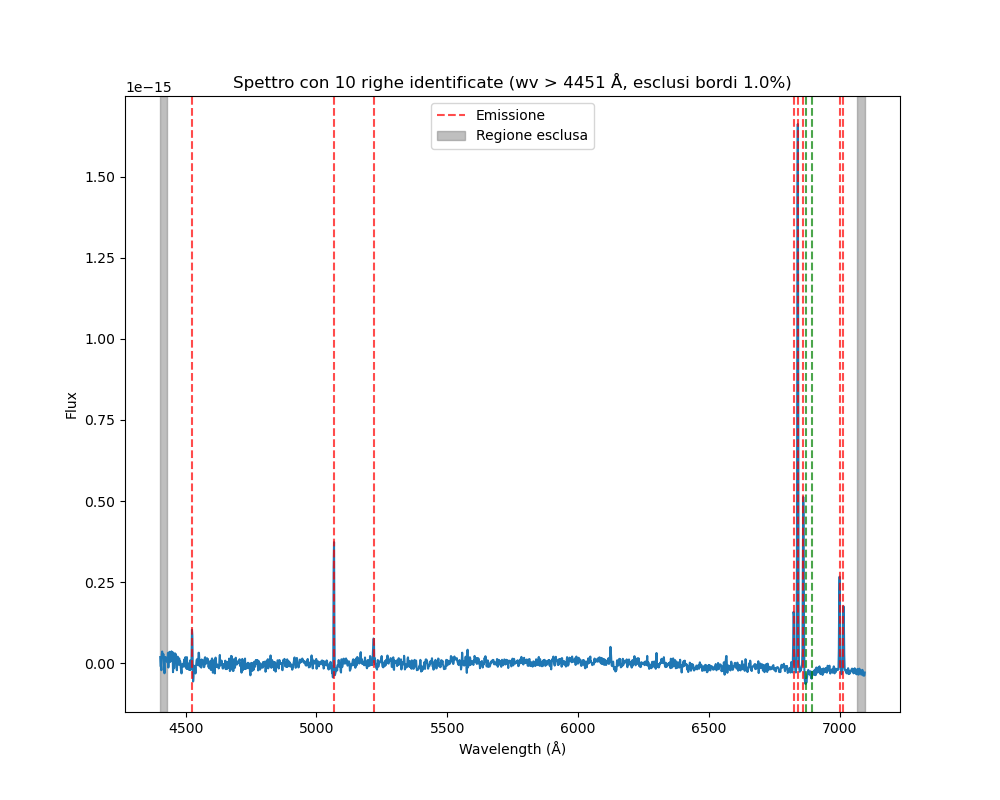

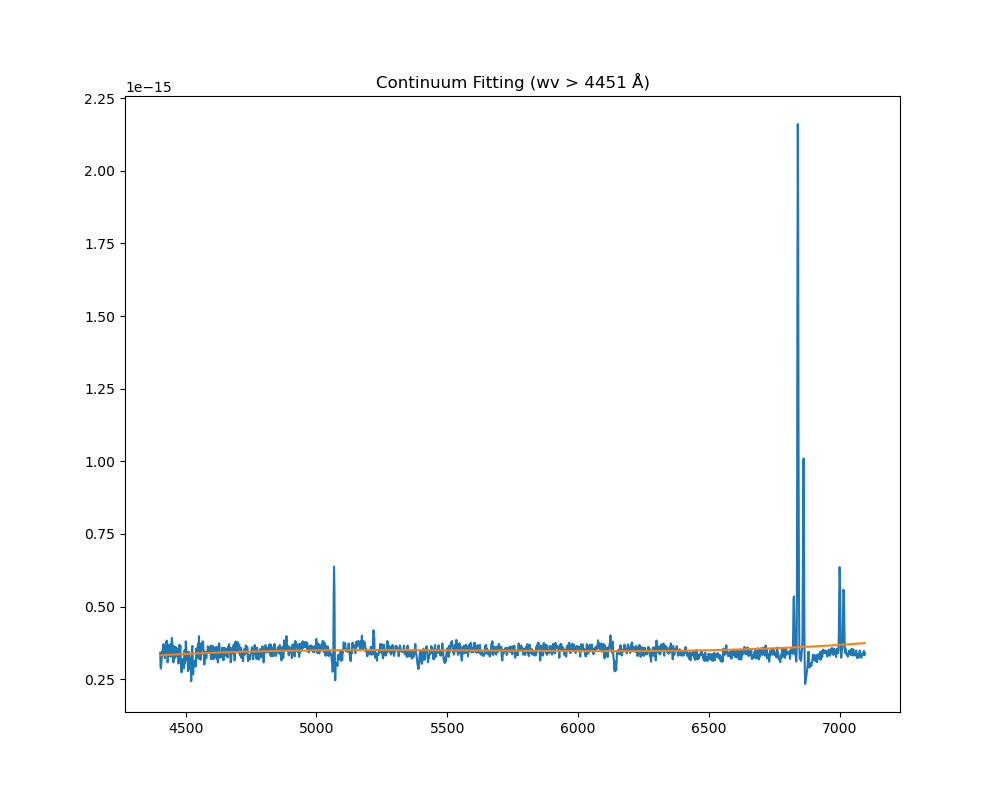

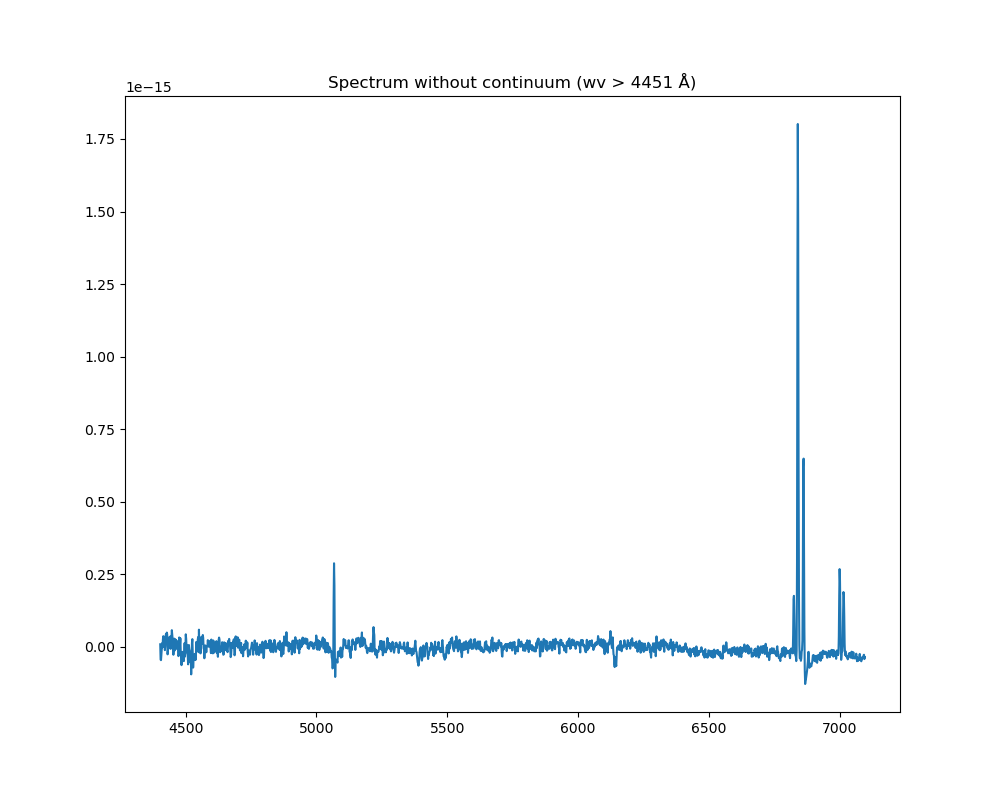

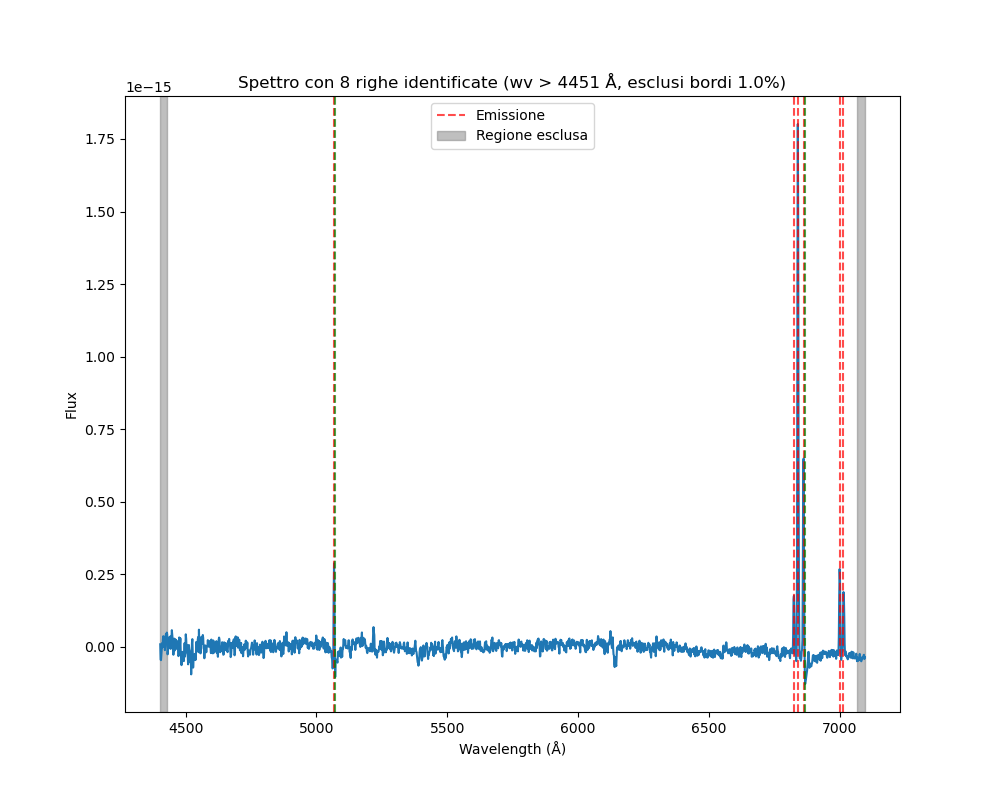

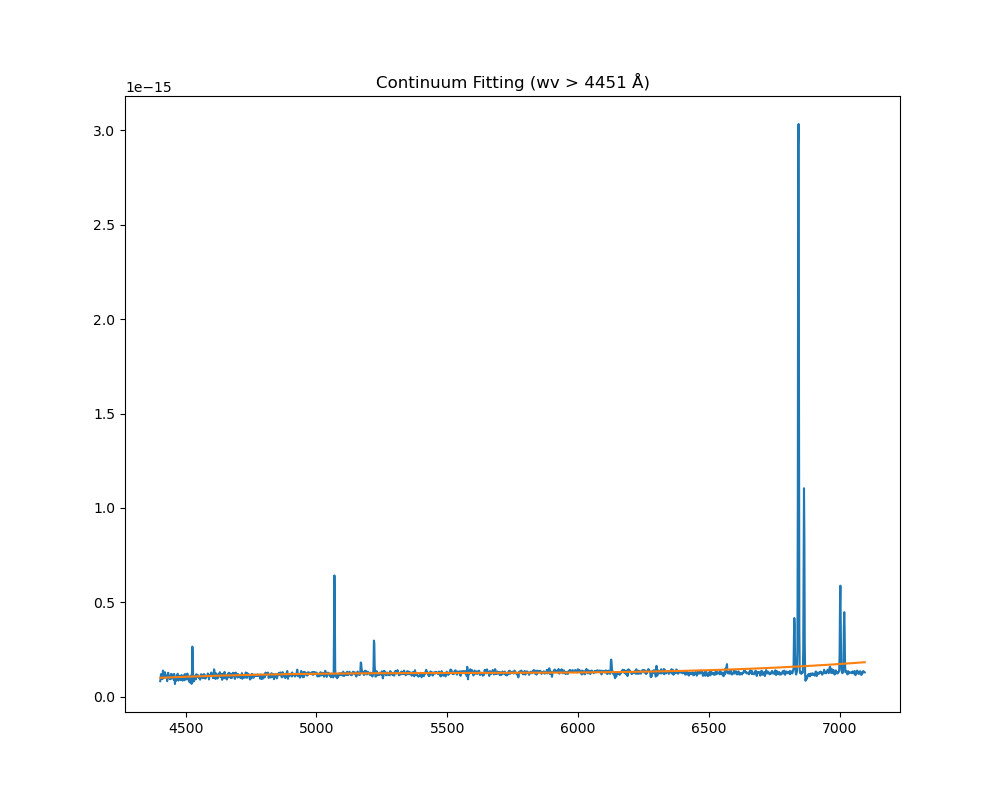

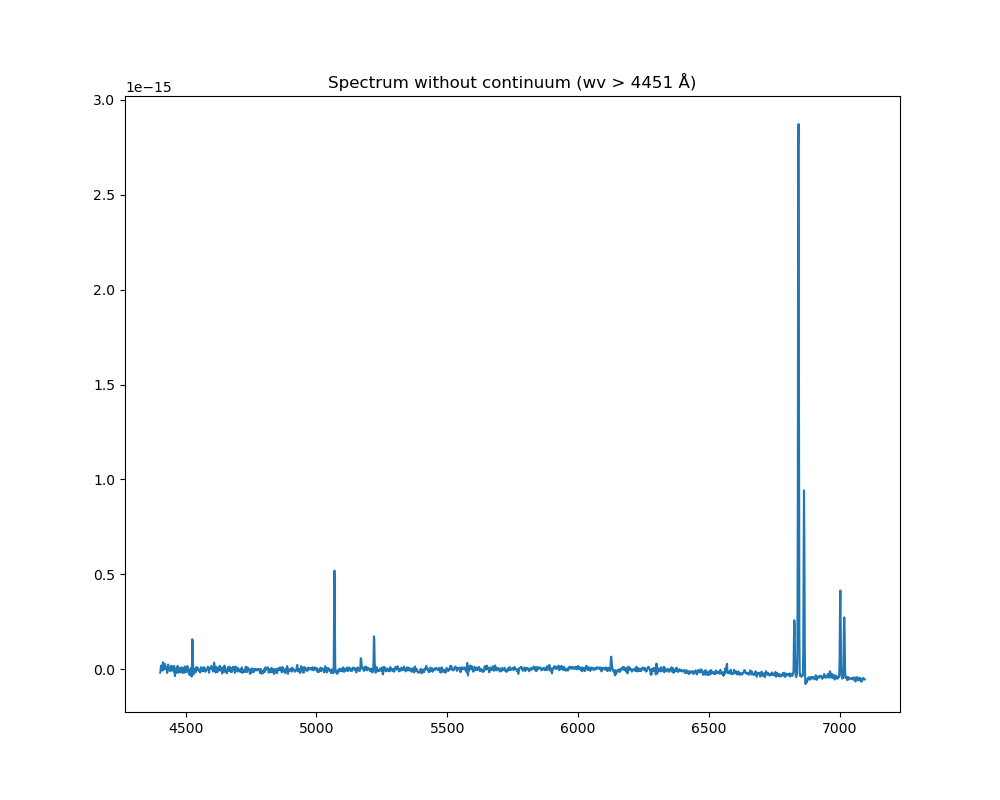

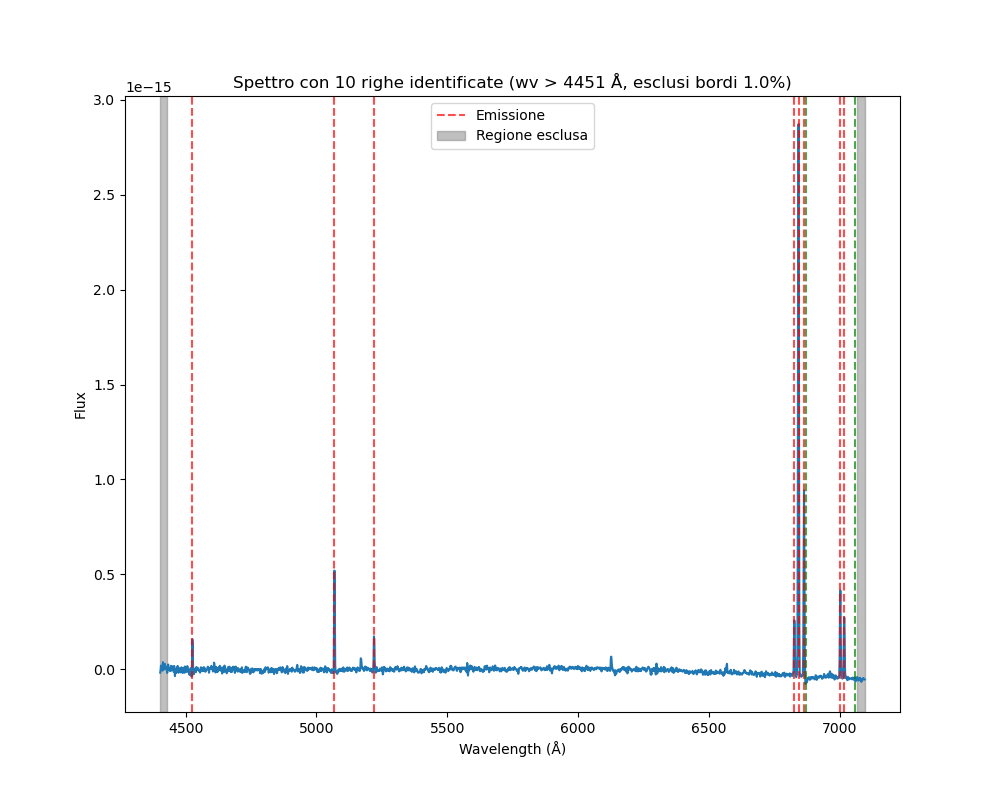

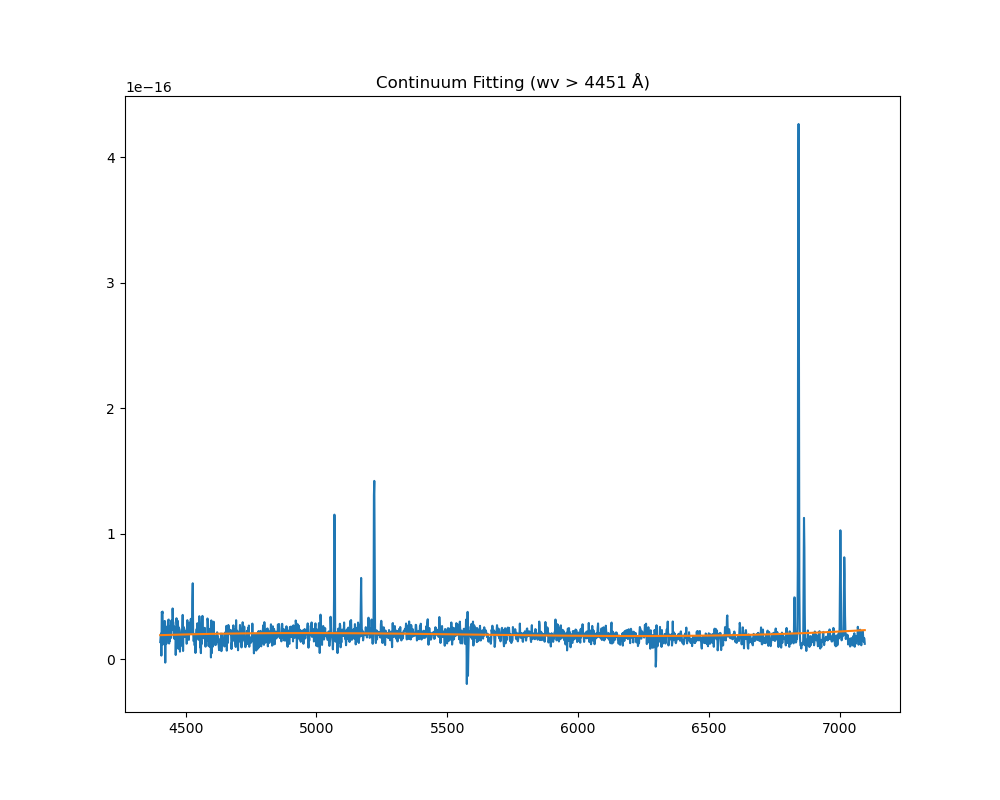

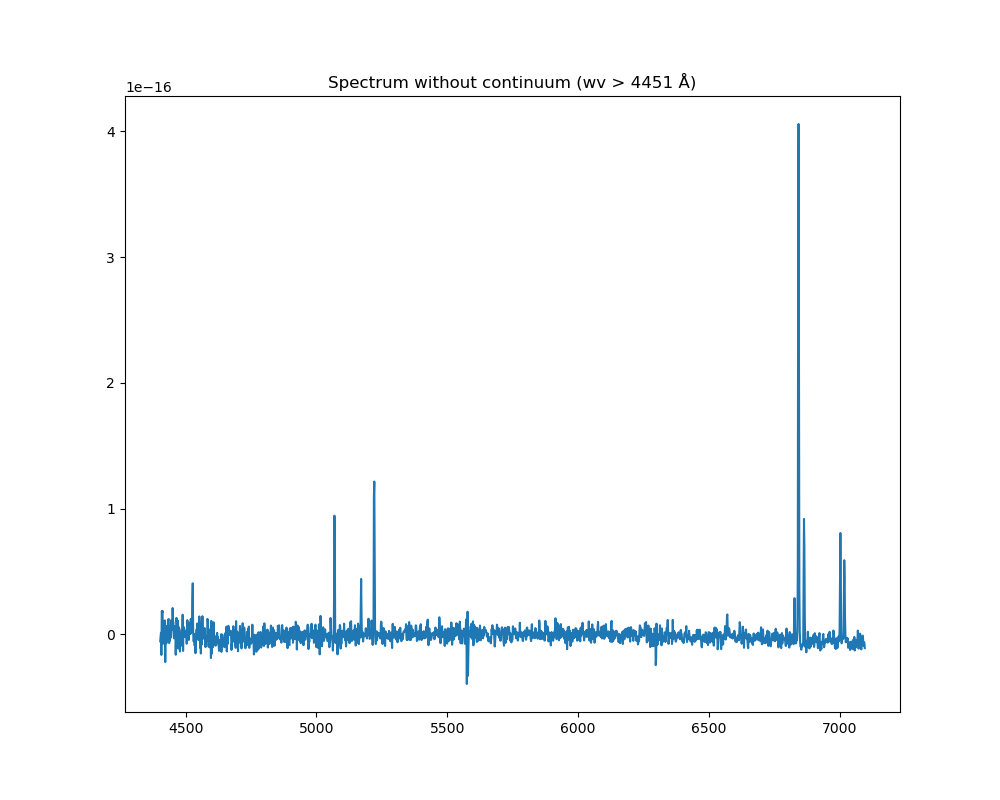

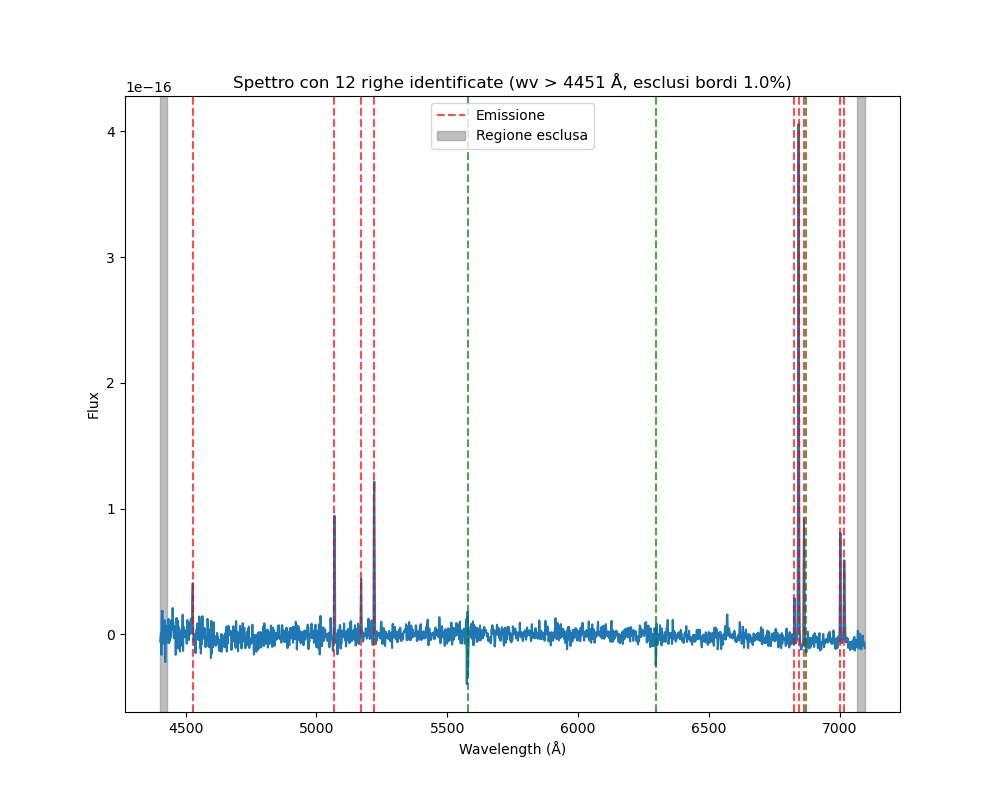

In [14]:
all_lines = []
noise_factor = [6, 5, 6, 8, 8, 4]

# Filtra per lunghezze d'ondaù > 4451 Å
wv_mask = wv > 4402
wv_filtered = wv[wv_mask]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv_filtered)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale (già filtrata per wv > 4451)
wv_central = wv_filtered[start_idx:end_idx]

for i in range(len(peaks)):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra_1[i][wv_mask]
    spectra_err_filtered = spectra_err_1[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv_filtered * u.Angstrom, spectra_filtered * 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv_filtered * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting (wv > 4451 Å)")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv_filtered * u.Angstrom, flux_continuum_subtracted)
    ax2.set_title("Spectrum without continuum (wv > 4451 Å)")
    
    # Crea lo spettro solo per la regione centrale (senza bordi, già filtrata per wv > 4451)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err_filtered[start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate (regione centrale, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            # Trova l'indice più vicino alla posizione della riga nell'array wv_central
            line_idx = np.argmin(np.abs(wv_central - line_pos.value))
            # Ottieni l'indice corrispondente nel flux completo
            flux_idx = start_idx + line_idx
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[flux_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv_filtered[0], wv_filtered[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv_filtered[end_idx-1], wv_filtered[-1], alpha=0.5, color='gray', zorder=1)
    ax3.legend()
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate (wv > 4451 Å, esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [15]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_1 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
#lines_2 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_3 = [l_Hgam, l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]  
lines_4 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_5 = [l_Hgam, l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]  
lines_6 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_1 = all_lines[0]['line_center'] 
lines_spectrum_2 = all_lines[1]['line_center']
lines_spectrum_3 = all_lines[2]['line_center']
lines_spectrum_4 = all_lines[3]['line_center'] 
lines_spectrum_5 = all_lines[4]['line_center']
lines_spectrum_6 = all_lines[5]['line_center']

z_1 = np.zeros(len(lines_1))
#z_2 = np.zeros(len(lines_2))
z_3 = np.zeros(len(lines_3))
z_4 = np.zeros(len(lines_4))
z_5 = np.zeros(len(lines_5))
z_6 = np.zeros(len(lines_6))

for i in range(len(lines_3)):
    z_5[i] = lines_spectrum_5[i].value / lines_5[i] - 1
    z_3[i] = lines_spectrum_3[i].value / lines_3[i] - 1
       
for i in range(len(lines_1)):    
    z_1[i] = lines_spectrum_1[i].value / lines_1[i] - 1
    
for i in range(len(lines_4)):
    z_4[i] = lines_spectrum_4[i].value / lines_4[i] - 1

for i in range(len(lines_6)):
    z_6[i] = lines_spectrum_6[i].value / lines_6[i] - 1
    
z_1_mean = np.mean(z_1)
#z_2_mean = np.mean(z_2)
z_3_mean = np.mean(z_3)
z_4_mean = np.mean(z_4)
z_5_mean = np.mean(z_5)
z_6_mean = np.mean(z_6)

z_1_std = np.std(z_1)
#z_2_std = np.std(z_2)
z_3_std = np.std(z_3)
z_4_std = np.std(z_4)
z_5_std = np.std(z_5)
z_6_std = np.std(z_6)

print(z_1_mean)
print(z_1_std)
print(z_3_mean)
print(z_3_std)
print(z_4_mean)
print(z_4_std)
print(z_5_mean)
print(z_5_std)
print(z_6_mean)
print(z_6_std)
  
z = [z_1_mean, np.nan, z_3_mean, z_4_mean, z_5_mean, z_6_mean]
z_err = [z_1_std, 0, z_3_std, z_4_std, z_5_std, z_6_std]

0.0421210286519683
0.00013573286752744597
0.0422426327921647
8.392864207321504e-05
0.04230240497010703
0.00010448032270041746
0.04263939650930815
6.066953896313737e-05
0.04272436598423665
0.00012859638462723948


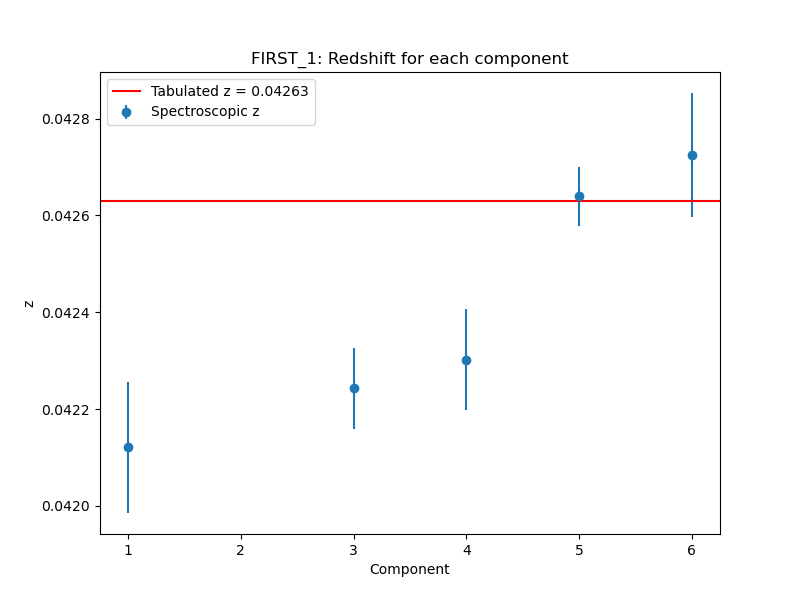

In [16]:
z = [z_1_mean, np.nan, z_3_mean, z_4_mean, z_5_mean, z_6_mean]
plt.figure(figsize=(8, 6))
comp = [1, 2, 3, 4, 5, 6]
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.04263, color = 'red', label = 'Tabulated z = 0.04263')
plt.title('FIRST_1: Redshift for each component')
plt.legend(loc='upper left')
plt.savefig('Redshift', bbox_inches='tight')

z = [z_1_mean, np.nan, z_3_mean, z_4_mean, z_5_mean, z_6_mean]
red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [17]:
def SNR_line(wv, wv_line, spectra, peaks): 
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > wv_line[i]-15)*(wv < wv_line[i]-5) 
        right_region = (wv > wv_line[i]+5)*(wv < wv_line[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > OIII_1[i]-15)*(wv < OIII_1[i]-5) 
        right_region = (wv > OIII_2[i]+5)*(wv < OIII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > SII_1[i]-15)*(wv < SII_1[i]-5) 
        right_region = (wv > SII_2[i]+5)*(wv < SII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > NII_1[i]-15)*(wv < NII_1[i]-5) 
        right_region = (wv > NII_2[i]+5)*(wv < NII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise  

In [18]:
l_Hgam = []
l_HA = []
l_HB = []
l_NII_1 = []
l_NII_2 = []
l_SII_1 = []
l_SII_2 = []
l_OIII_1 = []
l_OIII_2 = []
l_He_1 = []
l_HeII = []
l_OI = []
for i in range(len(spectra_1)):
    l_Hgam.append(4340.5*(1+z[i]))
    l_HA.append(6562.8*(1+z[i]))
    l_HB.append(4861.3*(1+z[i]))
    l_NII_1.append(6548.1*(1+z[i]))
    l_NII_2.append(6583.4*(1+z[i]))
    l_SII_1.append(6717.0*(1+z[i]))
    l_SII_2.append(6731.3*(1+z[i]))
    l_OIII_1.append(4958.9*(1+z[i]))
    l_OIII_2.append(5006.8*(1+z[i]))
    l_He_1.append(5875.6*(1+z[i]))
    l_HeII.append(4685.7*(1+z[i]))
    l_OI.append(6300.3*(1+z[i]))

In [19]:
def save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes):
    """
    Generalizza l'analisi SNR per multiple spectra
    
    Parameters:
    - wv: wavelength array
    - l_HB: line parameter
    - spectra_list: lista degli spettri da analizzare
    - peaks: peaks parameter
    - output_dirs: lista delle directory di output
    - file_prefixes: lista dei prefissi per i nomi dei file
    """
    
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, l_HB, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

def save_snr_OIII(wv, OIII_1, OIII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)
        
def save_snr_SII(wv, SII_1, SII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)


def save_snr_HA_NII(wv, NII_1, NII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

def save_snr(wv, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

In [20]:
spectra_list = [spectra_1, spectra_2, spectra_3]
output_dirs = ['1Sigma', '2Sigma', '3Sigma']
file_prefixes = ['SNR_HB_1s', 'SNR_HB_2s', 'SNR_HB_3s']
save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_1_1s', 'SNR_OIII_1_2s', 'SNR_OIII_1_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_2_1s', 'SNR_OIII_2_2s', 'SNR_OIII_2_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_1_1s', 'SNR_SII_1_2s', 'SNR_SII_1_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_2_1s', 'SNR_SII_2_2s', 'SNR_SII_2_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_1_1s', 'SNR_NII_1_2s', 'SNR_NII_1_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_2_1s', 'SNR_NII_2_2s', 'SNR_NII_2_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HA_1s', 'SNR_HA_2s', 'SNR_HA_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HeII_1s', 'SNR_HeII_2s', 'SNR_HeII_3s']
save_snr(wv, l_HeII, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OI_1s', 'SNR_OI_2s', 'SNR_OI_3s']
save_snr(wv, l_OI, spectra_list, peaks, output_dirs, file_prefixes)

C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=a

SNR_HB_1s.csv                     SNR     Signal     Noise
Component_1  118.405803  26.378812  0.222783
Component_2         NaN   0.000000       NaN
Component_3   33.884295  12.363229  0.364866
Component_4   18.342652  11.744314  0.640273
Component_5   81.821162  17.787434  0.217394
Component_6   13.073255   3.002571  0.229673
SNR_HB_2s.csv                     SNR     Signal     Noise
Component_1  131.625880  45.584345  0.346317
Component_2         NaN   0.000000       NaN
Component_3   34.571627  24.630127  0.712438
Component_4   21.244573  23.696797  1.115428
Component_5   71.668789  31.274573  0.436376
Component_6   20.992005   6.007486  0.286180
SNR_HB_3s.csv                     SNR     Signal     Noise
Component_1  139.388025  56.312638  0.403999
Component_2         NaN   0.000000       NaN
Component_3   39.948038  36.110251  0.903931
Component_4   24.011735  34.018989  1.416765
Component_5   73.631069  40.708596  0.552873
Component_6   25.747744   7.910495  0.307231
SNR_OIII_1_1s

C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ISAFA\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=a